### A) Import Data format Json dengan 

In [27]:
import json
import pandas as pd

def buka_file(nama_file):
    try:
        file = open(nama_file)
        data_aktivitas = json.load(file)

    except FileNotFoundError:
        print('Error = File tidak ditemukan')

    except json.JSONDecodeError:
        print('Error = Data korup')

    except Exception as e:
        print(f'Error = {e}')

    else:
        print('Data berhasil diproses')
        print("----------------------------")
        print(f'Jumlah Mahasiswa di data_aktivitas = {len(data_aktivitas)}')
        return data_aktivitas

data_aktivitas = buka_file("data_aktivitas_50_mahasiswa_time.json")
print(data_aktivitas)

Data berhasil diproses
----------------------------
Jumlah Mahasiswa di data_aktivitas = 50
[{'nim': 'A001', 'nama': 'Mahasiswa_01', 'kelas': 'B', 'log_harian': [{'tanggal': '2025-11-01', 'aktivitas': [{'jenis': 'tonton_video', 'waktu_mulai': '08:00:00', 'waktu_selesai': '08:15:00'}, {'jenis': 'baca_materi', 'halaman': 5, 'waktu_mulai': '08:20:00', 'waktu_selesai': '08:30:00'}]}, {'tanggal': '2025-11-02', 'aktivitas': [{'jenis': 'tonton_video', 'waktu_mulai': '08:00:00', 'waktu_selesai': '08:36:00'}]}, {'tanggal': '2025-11-03', 'aktivitas': [{'jenis': 'tonton_video', 'waktu_mulai': '08:00:00', 'waktu_selesai': '08:16:00'}, {'jenis': 'kerjakan_quiz', 'skor': 73, 'waktu_mulai': '08:21:00', 'waktu_selesai': '08:36:00'}, {'jenis': 'baca_materi', 'halaman': 12, 'waktu_mulai': '08:41:00', 'waktu_selesai': '08:51:00'}, {'jenis': 'forum_diskusi', 'waktu_mulai': '08:56:00', 'waktu_selesai': '09:01:00'}]}]}, {'nim': 'A002', 'nama': 'Mahasiswa_02', 'kelas': 'C', 'log_harian': [{'tanggal': '2025-1

### B) Membuat DataFrame Aktivitas

In [28]:
#dengan try except
def flatten_aktivitas(data_aktivitas):
    try:
        rows = []

        for mahasiswa in data_aktivitas:
            nim = mahasiswa['nim']
            nama = mahasiswa['nama']
            kelas = mahasiswa['kelas']
            for kegiatan in mahasiswa['log_harian']:
                tanggal =kegiatan['tanggal']

                for tipe in kegiatan['aktivitas']:
                    jenis = None
                    datetime_mulai = None
                    datetime_selesai = None
                    durasi = 0
                    waktu_mulai = None
                    waktu_selesai = None
                    skor = 0
                    halaman = 0
                    durasi = 0
                    
                    try:
                        jenis = tipe['jenis']
                        waktu_mulai = tipe['waktu_mulai']
                        waktu_selesai = tipe['waktu_selesai']
                       
                        if waktu_mulai and waktu_selesai:
                            datetime_mulai = pd.to_datetime(waktu_mulai)
                            datetime_selesai = pd.to_datetime(waktu_selesai)
                            durasi = (datetime_selesai - datetime_mulai).total_seconds()/60
                        
                    
                    except:
                        pass
                   
                    try:
                        skor = int(tipe['skor'])
                    
                    except (ValueError,TypeError,KeyError):
                        skor = 0
                        pass

                    try:
                        halaman = int(tipe['halaman'])

                    except (ValueError,TypeError,KeyError):
                        halaman = 0
                        pass

                    rows.append({
                        "nim": nim,
                        "nama": nama,
                        "kelas": kelas,
                        "tanggal": tanggal,
                        "jenis_aktivitas": jenis,
                        "waktu_mulai": waktu_mulai,
                        "waktu_selesai": waktu_selesai,
                        "datetime_mulai": datetime_mulai,
                        "datetime_selesai" : datetime_selesai,
                        "durasi_menit": durasi,
                        "skor_kuis": skor,
                        "halaman_baca": halaman
                    })
        
        return pd.DataFrame(rows)
    
    except Exception as e:
        print(f'Error = {e}')
        return None

try:
    df_aktivitas = flatten_aktivitas(data_aktivitas)

except Exception as e:
    print(f'Error = {e}')

else:
    print(df_aktivitas.head(10))
    print('------------------------------------------------')
    print(f'jumlah baris aktivitas = {len(df_aktivitas)}')


    nim          nama kelas     tanggal jenis_aktivitas waktu_mulai  \
0  A001  Mahasiswa_01     B  2025-11-01    tonton_video    08:00:00   
1  A001  Mahasiswa_01     B  2025-11-01     baca_materi    08:20:00   
2  A001  Mahasiswa_01     B  2025-11-02    tonton_video    08:00:00   
3  A001  Mahasiswa_01     B  2025-11-03    tonton_video    08:00:00   
4  A001  Mahasiswa_01     B  2025-11-03   kerjakan_quiz    08:21:00   
5  A001  Mahasiswa_01     B  2025-11-03     baca_materi    08:41:00   
6  A001  Mahasiswa_01     B  2025-11-03   forum_diskusi    08:56:00   
7  A002  Mahasiswa_02     C  2025-11-01    tonton_video    08:00:00   
8  A003  Mahasiswa_03     A  2025-11-01    tonton_video    08:00:00   
9  A003  Mahasiswa_03     A  2025-11-01   kerjakan_quiz    08:25:00   

  waktu_selesai      datetime_mulai    datetime_selesai  durasi_menit  \
0      08:15:00 2025-12-25 08:00:00 2025-12-25 08:15:00          15.0   
1      08:30:00 2025-12-25 08:20:00 2025-12-25 08:30:00          10.0   

### C) Membuat DataFrame Perilaku dari DataFrame Aktivitas

In [30]:
# 1. Menghitung metrik dasar: total_hari_aktif, total_aktivitas, dan variasi jenis aktivitas
# Mengelompokkan berdasarkan identitas mahasiswa
df_perilaku = df_aktivitas.groupby(['nim', 'nama', 'kelas']).agg(
    total_hari_aktif=('tanggal', 'nunique'),
    total_aktivitas=('nim', 'count'),
    jumlah_jenis_aktivitas_berbeda=('jenis_aktivitas', 'nunique')
).reset_index()

# 2. Menghitung total_durasi_video
# Filter hanya baris yang merupakan aktivitas menonton video
df_video = df_aktivitas[df_aktivitas['jenis_aktivitas'] == 'tonton_video']
summary_video = df_video.groupby('nim').agg(total_durasi_video=('durasi_menit', 'sum')).reset_index()

# 3. Menghitung jumlah_quiz
# Filter hanya baris yang merupakan aktivitas pengerjaan kuis
df_quiz = df_aktivitas[df_aktivitas['jenis_aktivitas'] == 'kerjakan_quiz']
summary_quiz = df_quiz.groupby('nim').agg(jumlah_quiz=('nim', 'count')).reset_index()

# 4. Menghitung rata2_skor_quiz
# Filter aktivitas kuis yang memiliki skor > 0 sesuai instruksi soal
df_quiz_skor = df_quiz[df_quiz['skor_kuis'] > 0]
summary_skor = df_quiz_skor.groupby('nim').agg(rata2_skor_quiz=('skor_kuis', 'mean')).reset_index()

# 5. Menggabungkan semua ringkasan ke dalam df_perilaku menggunakan merge
# Menggunakan how='left' agar mahasiswa yang tidak punya data video/kuis tidak hilang dari list
df_perilaku = pd.merge(df_perilaku, summary_video, on='nim', how='left')
df_perilaku = pd.merge(df_perilaku, summary_quiz, on='nim', how='left')
df_perilaku = pd.merge(df_perilaku, summary_skor, on='nim', how='left')

# 6. Menangani data kosong (NaN) pasca panggabungan
# Mengisi dengan 0 agar kolom tetap bertipe numerik dan siap diolah di Bagian (d)
df_perilaku[['total_durasi_video', 'jumlah_quiz', 'rata2_skor_quiz']] = \
    df_perilaku[['total_durasi_video', 'jumlah_quiz', 'rata2_skor_quiz']].fillna(0)

# Menampilkan hasil
print("--- Ringkasan Perilaku Mahasiswa (df_perilaku) ---")
print(df_perilaku.head(10))

--- Ringkasan Perilaku Mahasiswa (df_perilaku) ---
    nim          nama kelas  total_hari_aktif  total_aktivitas  \
0  A001  Mahasiswa_01     B                 3                7   
1  A002  Mahasiswa_02     C                 1                1   
2  A003  Mahasiswa_03     A                 4                9   
3  A004  Mahasiswa_04     B                 5                7   
4  A005  Mahasiswa_05     C                 5               13   
5  A006  Mahasiswa_06     A                 1                1   
6  A007  Mahasiswa_07     B                 2                3   
7  A008  Mahasiswa_08     C                 5                8   
8  A009  Mahasiswa_09     A                 4                6   
9  A010  Mahasiswa_10     B                 1                1   

   jumlah_jenis_aktivitas_berbeda  total_durasi_video  jumlah_quiz  \
0                               4                67.0          1.0   
1                               1                18.0          0.0   
2           

### D) Mencari Mahasiswa Hantu


In [31]:
def label_hantu(row):
    
    kriteria_1 = row['total_aktivitas'] >= 30
    
    
    kriteria_2 = row['total_durasi_video'] >= 600
    
    
    kriteria_3 = row['jumlah_quiz'] <= 1
    
    
    kriteria_4 = row['jumlah_jenis_aktivitas_berbeda'] <= 2
    
   
    if kriteria_1 and kriteria_2 and kriteria_3 and kriteria_4:
        return "POTENSIAL_HANTU"
    else:
       
        return "NORMAL"
    
df_perilaku['status'] = df_perilaku.apply(label_hantu, axis=1)
print(df_perilaku)

     nim          nama kelas  total_hari_aktif  total_aktivitas  \
0   A001  Mahasiswa_01     B                 3                7   
1   A002  Mahasiswa_02     C                 1                1   
2   A003  Mahasiswa_03     A                 4                9   
3   A004  Mahasiswa_04     B                 5                7   
4   A005  Mahasiswa_05     C                 5               13   
5   A006  Mahasiswa_06     A                 1                1   
6   A007  Mahasiswa_07     B                 2                3   
7   A008  Mahasiswa_08     C                 5                8   
8   A009  Mahasiswa_09     A                 4                6   
9   A010  Mahasiswa_10     B                 1                1   
10  A011  Mahasiswa_11     C                 4               14   
11  A012  Mahasiswa_12     A                 5                8   
12  A013  Mahasiswa_13     B                 5               12   
13  A014  Mahasiswa_14     C                 1                

### E) Ringkasan Per Kelas


In [32]:

ringkasan_hantu = {}


for kelas in sorted(df_perilaku["kelas"].unique()):
    # Filter data berdasarkan kelas
    df_kelas = df_perilaku[df_perilaku["kelas"] == kelas]
    

    total_mhs = len(df_kelas)
    
 
    jml_hantu = len(df_kelas[df_kelas["status"] == "POTENSIAL_HANTU"])
    
  
    persen_hantu = (jml_hantu / total_mhs * 100) if total_mhs > 0 else 0
    persen_hantu = round(persen_hantu, 2)
    
    ringkasan_hantu[kelas] = {
        "total_mahasiswa": total_mhs,
        "jumlah_potensial_hantu": jml_hantu,
        "persen_potensial_hantu": persen_hantu
    }

print(ringkasan_hantu)

{'A': {'total_mahasiswa': 16, 'jumlah_potensial_hantu': 0, 'persen_potensial_hantu': 0.0}, 'B': {'total_mahasiswa': 17, 'jumlah_potensial_hantu': 0, 'persen_potensial_hantu': 0.0}, 'C': {'total_mahasiswa': 17, 'jumlah_potensial_hantu': 0, 'persen_potensial_hantu': 0.0}}


### F) Laporan Ringkasan Hantu

In [51]:
print("--- LAPORAN RINGKASAN AKTIVITAS PER KELAS ---")

for kelas, data in ringkasan_hantu.items():
    print(f"Kelas {kelas}") 
    print(f"Total mahasiswa              : {data['total_mahasiswa']}") 
    print(f"Jumlah POTENSIAL_HANTU       : {data['jumlah_potensial_hantu']}") 
    print(f"Persentase POTENSIAL_HANTU   : {data['persen_potensial_hantu']} %") 
    print("-" * 30)

--- LAPORAN RINGKASAN AKTIVITAS PER KELAS ---
Kelas A
Total mahasiswa              : 16
Jumlah POTENSIAL_HANTU       : 0
Persentase POTENSIAL_HANTU   : 0.0 %
------------------------------
Kelas B
Total mahasiswa              : 17
Jumlah POTENSIAL_HANTU       : 0
Persentase POTENSIAL_HANTU   : 0.0 %
------------------------------
Kelas C
Total mahasiswa              : 17
Jumlah POTENSIAL_HANTU       : 0
Persentase POTENSIAL_HANTU   : 0.0 %
------------------------------


### G) Analisis Singkat

In [34]:

df_hantu_list = df_perilaku[df_perilaku["status"] == "POTENSIAL_HANTU"][["nim", "nama", "kelas"]]
print("\nDAFTAR MAHASISWA POTENSIAL HANTU:")
print(df_hantu_list)

contoh_hantu = df_perilaku[df_perilaku["status"] == "POTENSIAL_HANTU"]
contoh_normal = df_perilaku[(df_perilaku["status"] == "NORMAL")].iloc[1]

print('-------------------------------------------')
print(contoh_hantu)
print('-------------------------------------------')
print(contoh_normal)



DAFTAR MAHASISWA POTENSIAL HANTU:
Empty DataFrame
Columns: [nim, nama, kelas]
Index: []
-------------------------------------------
Empty DataFrame
Columns: [nim, nama, kelas, total_hari_aktif, total_aktivitas, jumlah_jenis_aktivitas_berbeda, total_durasi_video, jumlah_quiz, rata2_skor_quiz, status]
Index: []
-------------------------------------------
nim                                       A002
nama                              Mahasiswa_02
kelas                                        C
total_hari_aktif                             1
total_aktivitas                              1
jumlah_jenis_aktivitas_berbeda               1
total_durasi_video                        18.0
jumlah_quiz                                0.0
rata2_skor_quiz                            0.0
status                                  NORMAL
Name: 1, dtype: object


### H) Pattern Aktivitas Ideal

In [35]:
def extract_sequence(nim, df_aktivitas):
    
    df_mhs = df_aktivitas[df_aktivitas['nim'] == nim].copy()
    
    
    df_mhs = df_mhs.sort_values(by=['tanggal', 'waktu_mulai'])
    
    
    daily_sequences = df_mhs.groupby('tanggal')['jenis_aktivitas'].apply(list).tolist()
    
    ideal = ["tonton_video", "baca_materi", "kerjakan_quiz", "forum_diskusi"]
    reversed_ideal = ["forum_diskusi","kerjakan_quiz","baca_materi","tonton_video"]
    
    scores = []
        
    for seq in daily_sequences:
       
        if ideal == seq:
            scores.append(1.0)
       
        elif reversed_ideal == seq:
            scores.append(0.5)
        
        else:
            scores.append(0.0)
            
    
    return sum(scores) / len(scores)
    
   
rata2_ideal_list = []

for nim in df_perilaku['nim']:
    seq_data = extract_sequence(nim, df_aktivitas)
    rata2_ideal_list.append(seq_data)

 
df_perilaku['rata2_urut_ideal'] = rata2_ideal_list

print(df_perilaku)

contoh_mhs_tidak_ideal = df_perilaku[df_perilaku['rata2_urut_ideal'] == 0] 

contoh_mhs_hampir_ideal = df_perilaku[(df_perilaku['rata2_urut_ideal'] > 0) & (df_perilaku['rata2_urut_ideal'] < 1)]

print(len(contoh_mhs_hampir_ideal))
print(len(contoh_mhs_tidak_ideal))



     nim          nama kelas  total_hari_aktif  total_aktivitas  \
0   A001  Mahasiswa_01     B                 3                7   
1   A002  Mahasiswa_02     C                 1                1   
2   A003  Mahasiswa_03     A                 4                9   
3   A004  Mahasiswa_04     B                 5                7   
4   A005  Mahasiswa_05     C                 5               13   
5   A006  Mahasiswa_06     A                 1                1   
6   A007  Mahasiswa_07     B                 2                3   
7   A008  Mahasiswa_08     C                 5                8   
8   A009  Mahasiswa_09     A                 4                6   
9   A010  Mahasiswa_10     B                 1                1   
10  A011  Mahasiswa_11     C                 4               14   
11  A012  Mahasiswa_12     A                 5                8   
12  A013  Mahasiswa_13     B                 5               12   
13  A014  Mahasiswa_14     C                 1                

### I) Windowed Session Analysis: Efektivitas Sesi Belajar

    nim          nama  status  rata2_durasi_sesi  rata2_aktivitas_per_sesi  \
0  A001  Mahasiswa_01  NORMAL              107.0                       7.0   
1  A002  Mahasiswa_02  NORMAL               18.0                       1.0   
2  A003  Mahasiswa_03  NORMAL              130.0                       9.0   
3  A004  Mahasiswa_04  NORMAL              452.0                       7.0   
4  A005  Mahasiswa_05  NORMAL              281.0                      13.0   

   jumlah_sesi  
0            1  
1            1  
2            1  
3            1  
4            1  


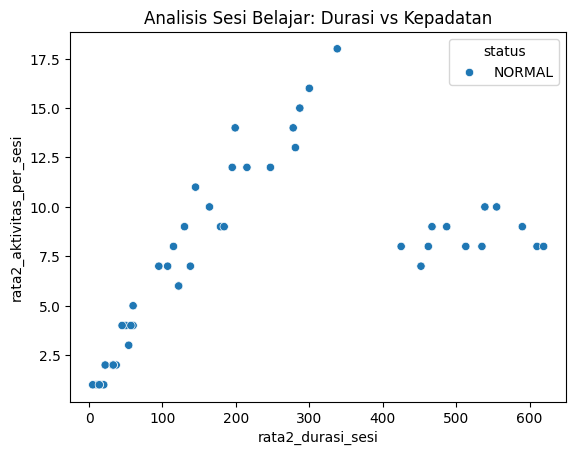

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

def segment_sessions(df_mhs):
    # a. Mengurutkan aktivitas berdasarkan waktu mulai 
    df_mhs = df_mhs.sort_values('datetime_mulai')
    
    # b. Menghitung jeda antar aktivitas (dalam menit) 
    # Jeda = waktu mulai sekarang - waktu selesai sebelumnya
    waktu_mulai = pd.to_datetime(df_mhs['datetime_mulai'])
    waktu_selesai_sebelumnya = pd.to_datetime(df_mhs['datetime_selesai'])
    jeda = (waktu_mulai - waktu_selesai_sebelumnya).dt.total_seconds() / 60
    
    # c. Menentukan ID sesi: jika jeda > 30 menit, maka sesi baru 
    df_mhs['session_id'] = (jeda > 30).fillna(True).cumsum()
    return df_mhs

# 1. Menjalankan segmentasi sesi untuk setiap mahasiswa
df_aktivitas = pd.concat([segment_sessions(df_aktivitas[df_aktivitas['nim'] == n]) for n in df_aktivitas['nim'].unique()])

# 2. Menghitung statistik per sesi menggunakan groupby dan agg 
# Tahap 1: Hitung total durasi dan jumlah aktivitas di tiap sesi per mahasiswa
session_data = df_aktivitas.groupby(['nim', 'session_id']).agg(
    durasi_sesi=('durasi_menit', 'sum'),
    jumlah_aktivitas=('nim', 'count')
).reset_index()

# Tahap 2: Hitung rata-rata statistik sesi per mahasiswa menggunakan groupby dan agg 
stats_sesi = session_data.groupby('nim').agg(
    rata2_durasi_sesi=('durasi_sesi', 'mean'),
    rata2_aktivitas_per_sesi=('jumlah_aktivitas', 'mean'),
    jumlah_sesi=('session_id', 'count')
).reset_index()

# 3. Menggabungkan hasil ke df_perilaku menggunakan merge 
# Pastikan menghapus kolom lama jika ada untuk menghindari duplikasi
cols_to_drop = ['rata2_durasi_sesi', 'rata2_aktivitas_per_sesi', 'jumlah_sesi']
df_perilaku = df_perilaku.drop(columns=[c for c in cols_to_drop if c in df_perilaku.columns])
df_perilaku = pd.merge(df_perilaku, stats_sesi, on='nim', how='left').fillna(0)

# 4. Visualisasi Scatterplot 
sns.scatterplot(
    data=df_perilaku, 
    x='rata2_durasi_sesi', 
    y='rata2_aktivitas_per_sesi', 
    hue='status'
)
plt.title("Analisis Sesi Belajar: Durasi vs Kepadatan")
plt.savefig('analisis_sesi_final.png')

# Menampilkan 5 baris pertama hasil analisis 
print(df_perilaku[['nim', 'nama', 'status', 'rata2_durasi_sesi', 'rata2_aktivitas_per_sesi', 'jumlah_sesi']].head())

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# FUNGSI SEGMENTASI SESI BELAJAR
# ===============================
def segment_sessions(df_aktivitas_per_mahasiswa):
    """
    Membagi aktivitas mahasiswa ke dalam sesi belajar
    Satu sesi jika jeda antar aktivitas <= 30 menit
    """
    df = df_aktivitas_per_mahasiswa.copy()
    df = df.sort_values("datetime_mulai")

    session_ids = []
    session_counter = 1
    last_time = None

    for _, row in df.iterrows():
        if pd.isna(row["datetime_mulai"]):
            session_ids.append(None)
            continue

        if last_time is None:
            session_ids.append(session_counter)
        else:
            selisih_menit = (row["datetime_mulai"] - last_time).total_seconds() / 60
            if selisih_menit > 30:
                session_counter += 1
            session_ids.append(session_counter)

        last_time = row["datetime_mulai"]

    df["session_id"] = session_ids
    return df


# ==================================
# TERAPKAN KE SELURUH MAHASISWA
# ==================================
df_sesi_list = []

for nim in df_aktivitas["nim"].unique():
    df_mhs = df_aktivitas[df_aktivitas["nim"] == nim]
    df_mhs_sesi = segment_sessions(df_mhs)
    df_sesi_list.append(df_mhs_sesi)

df_aktivitas_sesi = pd.concat(df_sesi_list, ignore_index=True)


# ==================================
# HITUNG STATISTIK SESI PER MAHASISWA
# ==================================
hasil_sesi = []

for nim in df_aktivitas_sesi["nim"].unique():
    df_mhs = df_aktivitas_sesi[df_aktivitas_sesi["nim"] == nim]

    sesi_group = df_mhs.groupby("session_id")

    durasi_per_sesi = sesi_group["durasi_menit"].sum()
    aktivitas_per_sesi = sesi_group.size()

    hasil_sesi.append({
        "nim": nim,
        "rata2_durasi_sesi": durasi_per_sesi.mean(),
        "rata2_aktivitas_per_sesi": aktivitas_per_sesi.mean(),
        "jumlah_sesi": sesi_group.ngroups
    })

df_sesi_summary = pd.DataFrame(hasil_sesi)



df_perilaku = df_perilaku.merge(df_sesi_summary, on="nim", how="left")



for label in df_perilaku["status"].unique():
    df_plot = df_perilaku[df_perilaku["status"] == label]
    plt.scatter(
        df_plot["rata2_durasi_sesi"],
        df_plot["rata2_aktivitas_per_sesi"],
        label=label
    )

plt.xlabel("Rata-rata Durasi Sesi (menit)")
plt.ylabel("Rata-rata Aktivitas per Sesi")
plt.title("Analisis Efektivitas Sesi Belajar Mahasiswa")
plt.legend()
plt.show()


print(df_perilaku)

MergeError: Passing 'suffixes' which cause duplicate columns {'rata2_durasi_sesi_x', 'jumlah_sesi_x', 'rata2_aktivitas_per_sesi_x'} is not allowed.